In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_dir ="dataset_split/train"
val_dir ="dataset_split/val"
test_dir ="dataset_split/test"

# Augmentation untuk data train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & test tidak perlu augmentation
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class labels:", train_generator.class_indices)

Found 6485 images belonging to 3 classes.
Found 811 images belonging to 3 classes.
Found 811 images belonging to 3 classes.
Class labels: {'Anorganik': 0, 'Organik': 1, 'Toxic': 2}


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze layer supaya tidak ikut training
for layer in base_model.layers:
    layer.trainable = False

# Tambahkan classifier baru
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 15s 2us/step


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

C:\Users\bintang\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 724s 3s/step - accuracy: 0.7937 - loss: 0.4631 - val_accuracy: 0.8274 - val_loss: 0.3073
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 597s 3s/step - accuracy: 0.8432 - loss: 0.3125 - val_accuracy: 0.8570 - val_loss: 0.2644
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 556s 3s/step - accuracy: 0.8500 - loss: 0.2715 - val_accuracy: 0.8422 - val_loss: 0.2469
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 579s 3s/step - accuracy: 0.8512 - loss: 0.2602 - val_accuracy: 0.8323 - val_loss: 0.2525
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 716s 3s/step - accuracy: 0.8521 - loss: 0.2600 - val_accuracy: 0.8594 - val_loss: 0.2517
Epoch 6/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 625s 3s/step - accuracy: 0.8614 - loss: 0.2492 - val_accuracy: 0.8483 - val_loss: 0.2413
Epoch 7/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 563s 3s/step - accuracy: 0.8612 - loss: 0.2417 - val_accuracy: 0.8483 - val_loss: 0.2346
Epoch 8/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 624s 3s/step - accuracy: 0.8678 - loss: 0.2285 - val_accu

In [9]:
model.save("model_sampah.h5")

In [10]:
model.save("model_sampah.keras")

In [3]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
model = load_model("model_sampah.h5")

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224  # sesuaikan dengan training kamu
BATCH_SIZE = 32

test_dir = "dataset_split/test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 811 images belonging to 3 classes.


In [14]:
test_generator.reset()

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

from sklearn.metrics import classification_report, confusion_matrix

labels = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=labels))
print(confusion_matrix(y_true, y_pred_classes))

C:\Users\bintang\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step
              precision    recall  f1-score   support

   Anorganik       0.94      0.99      0.97       341
     Organik       0.84      0.61      0.70       254
       Toxic       0.66      0.82      0.73       216

    accuracy                           0.83       811
   macro avg       0.81      0.81      0.80       811
weighted avg       0.83      0.83      0.82       811

[[339   2   0]
 [ 10 154  90]
 [ 11  28 177]]


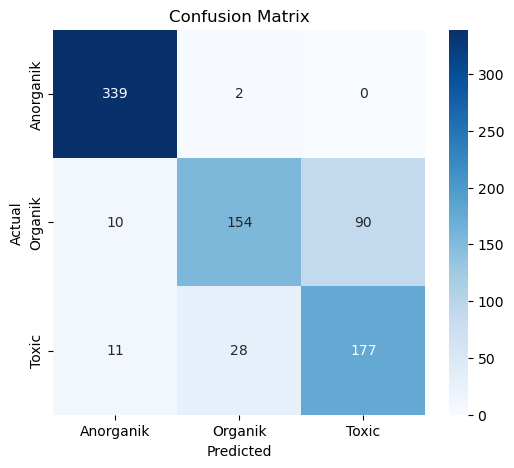

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()